In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
import json
import numpy as np
from src.data_loader import load_raw_data
from src.preprocessing import clean_raw_data, chronological_split, fit_scaler, apply_scaler, inverse_transform_column
from src.feature_engineering import build_features
from src.sequence_builder import create_sequences_for_all_splits
from src.evaluation.metrics import evaluate_all
from src.config import MODEL_FEATURE_COLUMNS, TARGET_COL, DEFAULT_LOOKBACK, FORECAST_HORIZON

DEV_LOOKBACK = 72  # temporary, for fast iteration — NOT the final 168

df_raw = load_raw_data()
df_clean = clean_raw_data(df_raw)
df_features = build_features(df_clean)
splits = chronological_split(df_features)

scale_columns = MODEL_FEATURE_COLUMNS + [TARGET_COL]
scaler = fit_scaler(splits.train, scale_columns)

train_scaled = apply_scaler(splits.train, scaler, scale_columns)
val_scaled = apply_scaler(splits.val, scaler, scale_columns)
test_scaled = apply_scaler(splits.test, scaler, scale_columns)

sequences = create_sequences_for_all_splits(train_scaled, val_scaled, test_scaled, MODEL_FEATURE_COLUMNS)
X_train, y_train_scaled = sequences["train"]
X_val, y_val_scaled = sequences["val"]
X_test, y_test_scaled = sequences["test"]

print("Ready:", X_train.shape, X_val.shape, X_test.shape)

2026-09-12 19:12:18 | INFO     | src.data_loader | Loading raw dataset from C:\Users\Ram\OneDrive\Desktop\energy-demand-lstm\data\raw\continuous_dataset.csv
2026-09-12 19:12:19 | INFO     | src.data_loader | Loaded raw dataset: 48048 rows, 17 columns
2026-09-12 19:12:19 | INFO     | src.preprocessing | Cleaning complete: 48048 rows, 4 flagged as diagnostic extreme events (|z| > 4.0)
2026-09-12 19:12:19 | INFO     | src.feature_engineering | Added national weather averages: temp_avg, humidity_avg, precip_avg, wind_avg
2026-09-12 19:12:20 | INFO     | src.feature_engineering | Added calendar features and cyclical encodings
2026-09-12 19:12:20 | INFO     | src.feature_engineering | Added lag features: ['lag_1', 'lag_24', 'lag_48', 'lag_168']
2026-09-12 19:12:20 | INFO     | src.feature_engineering | Added rolling features: rolling_mean_24, rolling_std_24, rolling_mean_168
2026-09-12 19:12:20 | INFO     | src.feature_engineering | Feature engineering complete: 48048 rows before, 47880 rows

In [3]:
import os
import torch
torch.set_num_threads(os.cpu_count())

from src.models.transformer import TransformerForecaster
from src.training.trainer import train_model, predict

transformer_model = TransformerForecaster(num_features=X_train.shape[2])
transformer_history = train_model(transformer_model, X_train, y_train_scaled, X_val, y_val_scaled, epochs=10)

print("Epochs trained:", transformer_history["epochs_trained"])
print("Parameters:", transformer_history["num_parameters"])
print("Training time (s):", round(transformer_history["training_time_seconds"], 1))

2026-09-12 19:12:43 | INFO     | src.training.trainer | Training TransformerForecaster | 36376 parameters | device=cpu
2026-09-12 19:12:43 | INFO     | src.training.trainer |   batch 0/131
2026-09-12 19:14:30 | INFO     | src.training.trainer |   batch 100/131
2026-09-12 19:15:14 | INFO     | src.training.trainer | Epoch 1/10 | train_loss=0.040096 | val_loss=0.013644
2026-09-12 19:15:15 | INFO     | src.training.trainer |   batch 0/131
2026-09-12 19:16:54 | INFO     | src.training.trainer |   batch 100/131
2026-09-12 19:17:32 | INFO     | src.training.trainer | Epoch 2/10 | train_loss=0.007372 | val_loss=0.005824
2026-09-12 19:17:32 | INFO     | src.training.trainer |   batch 0/131
2026-09-12 19:19:01 | INFO     | src.training.trainer |   batch 100/131
2026-09-12 19:19:46 | INFO     | src.training.trainer | Epoch 3/10 | train_loss=0.004064 | val_loss=0.004228
2026-09-12 19:19:46 | INFO     | src.training.trainer |   batch 0/131
2026-09-12 19:21:13 | INFO     | src.training.trainer |   

In [4]:
from src.evaluation.metrics import evaluate_all
from src.preprocessing import inverse_transform_column
from src.config import TARGET_COL

y_pred_test_scaled = predict(transformer_model, X_test)
y_true_transformer = inverse_transform_column(y_test_scaled, scaler, scale_columns, TARGET_COL)
y_pred_transformer = inverse_transform_column(y_pred_test_scaled, scaler, scale_columns, TARGET_COL)

transformer_metrics = evaluate_all(y_true_transformer, y_pred_transformer)
print("Transformer:", transformer_metrics)

Transformer: {'MAE': 73.77266826742938, 'RMSE': 103.44833472481274, 'MAPE': 6.35630448519236, 'sMAPE': 6.1368359016345435, 'R2': 0.6860666353952469}


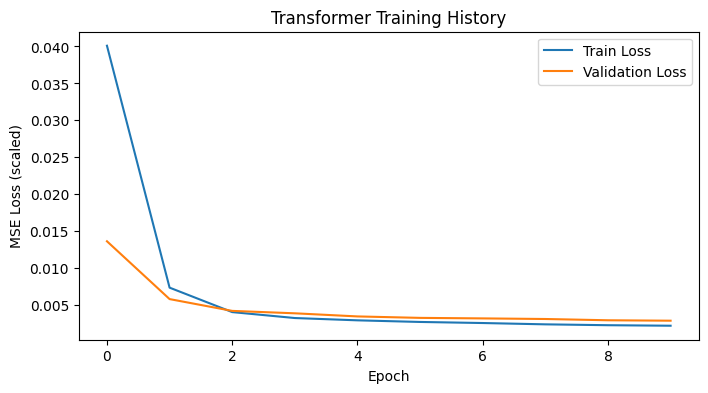

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(transformer_history["train_loss"], label="Train Loss")
ax.plot(transformer_history["val_loss"], label="Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss (scaled)")
ax.set_title("Transformer Training History")
ax.legend()
plt.show()

In [6]:
import json
from pathlib import Path
import pandas as pd

experiments_path = Path.cwd().parent / "experiments" / "model_comparison.json"
with open(experiments_path) as f:
    all_results = json.load(f)

all_results["Transformer"] = {
    **transformer_metrics,
    "training_time_seconds": transformer_history["training_time_seconds"],
    "num_parameters": transformer_history["num_parameters"],
}
with open(experiments_path, "w") as f:
    json.dump(all_results, f, indent=2)

comparison = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k in ["MAE", "RMSE", "MAPE", "sMAPE", "R2"]}
    for name, metrics in all_results.items()
}).T
print(comparison)
print("\nSaved Transformer to experiments/model_comparison.json")

                                                          MAE        RMSE  \
Naive                                              165.833298  213.037689   
Moving Average                                     132.922394  165.120346   
Linear Regression                                   92.602806  117.556152   
Simple RNN                                         132.609752  169.438917   
Simple RNN (DEV CONFIG - not directly comparable)  135.653897  173.374671   
LSTM                                                67.422624   93.767627   
Univariate LSTM                                     79.758896  106.028036   
Stacked LSTM                                        69.655762   97.959247   
BiLSTM (experiment)                                 66.391543   91.860677   
Attention-LSTM                                      86.769918  112.721887   
GRU                                                 71.905100   97.205096   
Transformer                                         73.772668  103.448335   

In [7]:
import json
from pathlib import Path

experiments_path = Path.cwd().parent / "experiments" / "model_comparison.json"
with open(experiments_path) as f:
    all_results = json.load(f)

print(json.dumps(all_results["Simple RNN"], indent=2))

{
  "MAE": 132.60975220161936,
  "RMSE": 169.43891698064303,
  "MAPE": 10.631912397436812,
  "sMAPE": 10.98026568074364,
  "R2": 0.15875217132673147,
  "training_time_seconds": 17.2950336933136,
  "num_parameters": 7064
}
